In [1]:
import requests
from IPython.display import display, HTML
import base64
from PIL import Image
import io

def send_image_and_visualize(
    image_path: str,
    api_url: str = "http://localhost:8000/infer_image",
    threshold: float = 0.5,
    visualize: bool = True
):
    """
    Sends an image to inference API and visualizes the result in Jupyter Notebook.
    
    Args:
        image_path: Path to local image file (e.g., 'test.jpg')
        api_url: URL of your FastAPI /infer_image endpoint
        threshold: Detection confidence threshold
        visualize: Whether to request visualization from server
    """
    # Step 1: Prepare and send request
    with open(image_path, "rb") as f:
        files = {"file": f}
        params = {"threshold": threshold, "visualize": visualize}

        print("Sending request to server...")
        response = requests.post(api_url, files=files, params=params)

    if response.status_code != 200:
        raise Exception(f"Server returned error: {response.status_code} - {response.text}")

    result = response.json()
    print("Inference completed successfully.")

    # Step 2: Extract visualization (base64 string)
    vis_b64 = result.get("visualization")

    if vis_b64:
        # Display the already-drawn image from the server
        html_img = f'<img src="data:image/png;base64,{vis_b64}" style="max-width: 100%;">'
        display(HTML(html_img))
    else:
        print("No visualization was returned by the server.")

In [16]:
import glob,os
image_paths = glob.glob(r'D:\Work\Build\FasterRCNN-Torchvision-FineTuning\dataset\AquariumDataset\train\images\*')

image_path = image_paths[112]
print(os.path.basename(image_path))

IMG_2440_jpeg_jpg.rf.fbf8154be50fdc05cf5c49e452c8889a.jpg


Sending request to server...
Inference completed successfully.



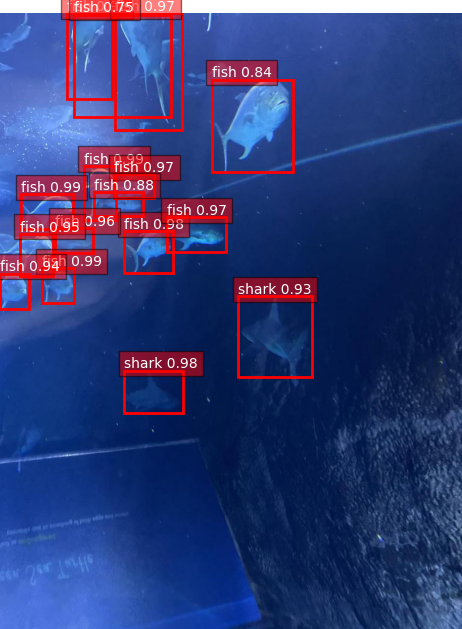

In [17]:
# Example usage
send_image_and_visualize(
    image_path=image_path,         # Replace with your image path
    api_url="http://localhost:8000/infer_image",
    threshold=0.5,
    visualize=True
)